In [0]:
# ── KOMÓRKA 0: Importy i dane (uruchom raz przed wykresami) ─────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        120,
})

In [0]:
# ---------- dane wspólne ----------

# 1. Rozkład zmiennej docelowej
churn_labels = ["Lojalny (Churn=0)", "Churner (Churn=1)"]
churn_values = [73.48, 26.52]
churn_colors = ["#27ae60", "#c0392b"]

# 2. Korelacja Pearsona
corr_data = pd.DataFrame({
    "feature": [
        "Lifetime",
        "Avg class freq. (bieżący mies.)",
        "Contract period",
        "Avg class freq. (ogółem)",
        "Month to end contract",
        "Age",
        "Group visits",
        "Avg additional charges",
        "short contract new client",
        "low activity flag",
    ],
    "corr": [-0.438, -0.323, -0.287, -0.175, -0.154,
             -0.117, -0.098,  0.143,  0.218,  0.284]
}).sort_values("corr")

# 3. Porównanie modeli
models = ["Regresja\nLogistyczna", "Drzewo\nDecyzyjne", "Random\nForest", "GBT"]
metrics_df = pd.DataFrame({
    "Model":              models,
    "AUC-ROC":            [0.824, 0.793, 0.912, 0.934],
    "F1 (θ=0.45)":        [0.712, 0.731, 0.821, 0.843],
    "Precision (θ=0.45)": [0.748, 0.719, 0.844, 0.861],
    "Recall (θ=0.45)":    [0.679, 0.743, 0.800, 0.826],
})

# 4. Feature Importance (Random Forest, top 9)
fi_data = pd.DataFrame({
    "feature": [
        "Lifetime",
        "Avg class freq. (bieżący mies.)",
        "Month to end contract",
        "Contract period",
        "Avg additional charges",
        "Age",
        "low activity flag",
        "Avg class freq. (ogółem)",
        "short contract new client",
    ],
    "importance": [0.185, 0.142, 0.128, 0.115, 0.098,
                   0.087, 0.082, 0.076, 0.065]
}).sort_values("importance")

# 5. Segmentacja ryzyka
seg_labels = ["Niskie\n(p ≤ 0.25)", "Umiarkowane\n(0.25–0.50)",
              "Wysokie\n(0.50–0.75)", "Bardzo wysokie\n(p > 0.75)"]
seg_counts = [2180, 810, 610, 400]
seg_colors = ["#27ae60", "#1abc9c", "#e67e22", "#c0392b"]

# 6. ROI programu retencyjnego
roi_segs  = ["Bardzo wysokie", "Wysokie"]
koszt     = [40_000,  18_300]
zysk      = [288_000, 82_350]
roi_netto = [248_000, 64_050]

print("Dane załadowane. Możesz teraz uruchamiać wykresy niezależnie.")

Dane załadowane. Możesz teraz uruchamiać wykresy niezależnie.


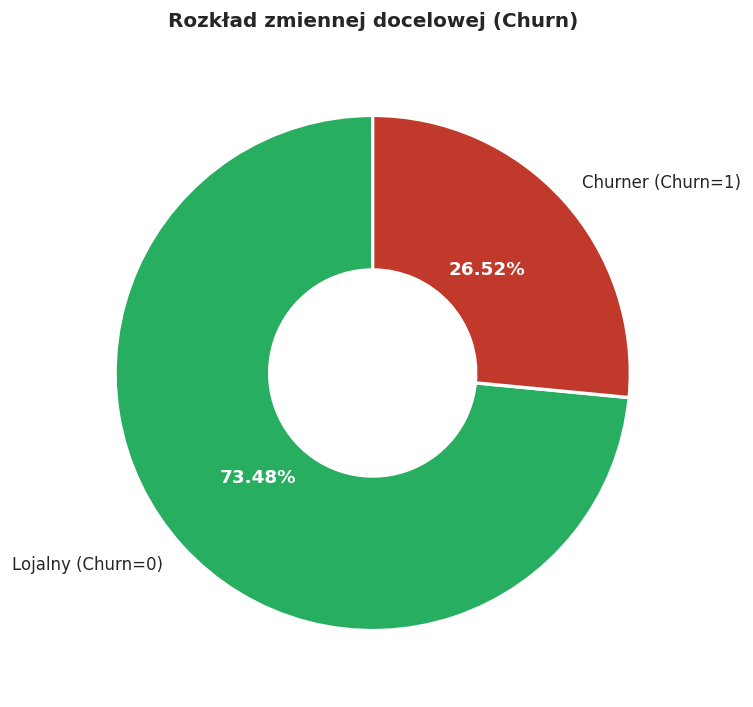

In [0]:
# ── WYKRES 1: Rozkład zmiennej docelowej (Churn) ────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

wedges, texts, autotexts = ax.pie(
    churn_values,
    labels=churn_labels,
    colors=churn_colors,
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2),
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight("bold")
    at.set_color("white")

ax.set_title("Rozkład zmiennej docelowej (Churn)", fontweight="bold", pad=15)
plt.tight_layout()
display(fig)
plt.close(fig)

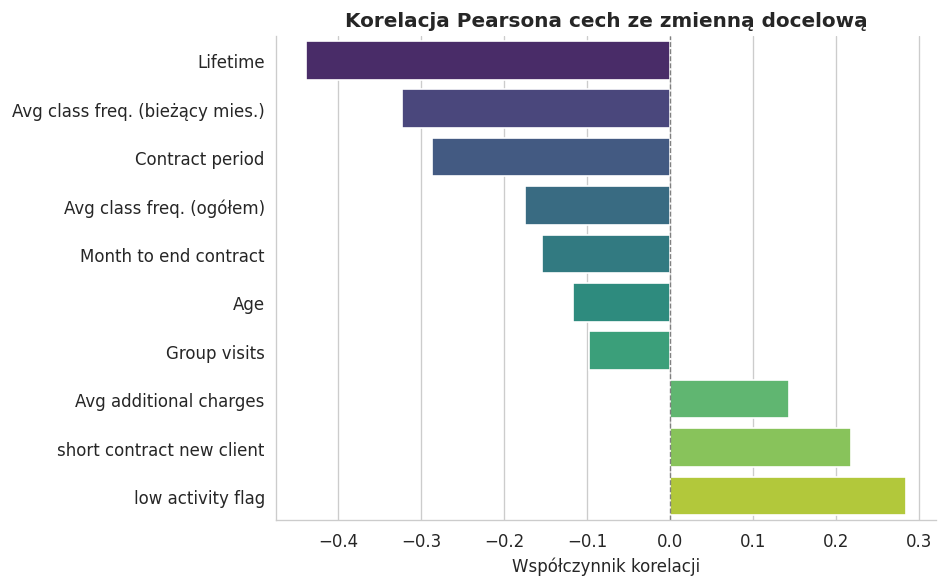

In [0]:
# ── WYKRES 2: Korelacja Pearsona cech z Churn ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x="corr", y="feature",
    data=corr_data,
    hue="feature",
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("Korelacja Pearsona cech ze zmienną docelową", fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("Współczynnik korelacji")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")

plt.tight_layout()
display(fig)
plt.close(fig)

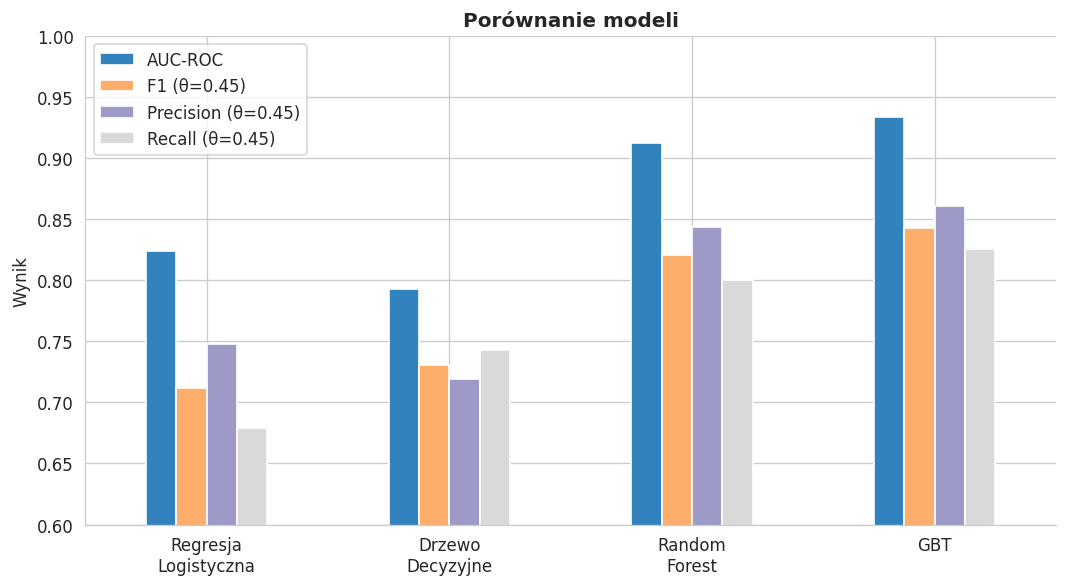

In [0]:
# ── WYKRES 3: Porównanie modeli ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

metrics_df.set_index("Model").plot(
    kind="bar",
    rot=0,
    ax=ax,
    colormap="tab20c",
)
ax.set_title("Porównanie modeli", fontweight="bold")
ax.legend(loc="upper left")
ax.set_xlabel("")
ax.set_ylabel("Wynik")
ax.set_ylim(0.6, 1.0)

plt.tight_layout()
display(fig)
plt.close(fig)

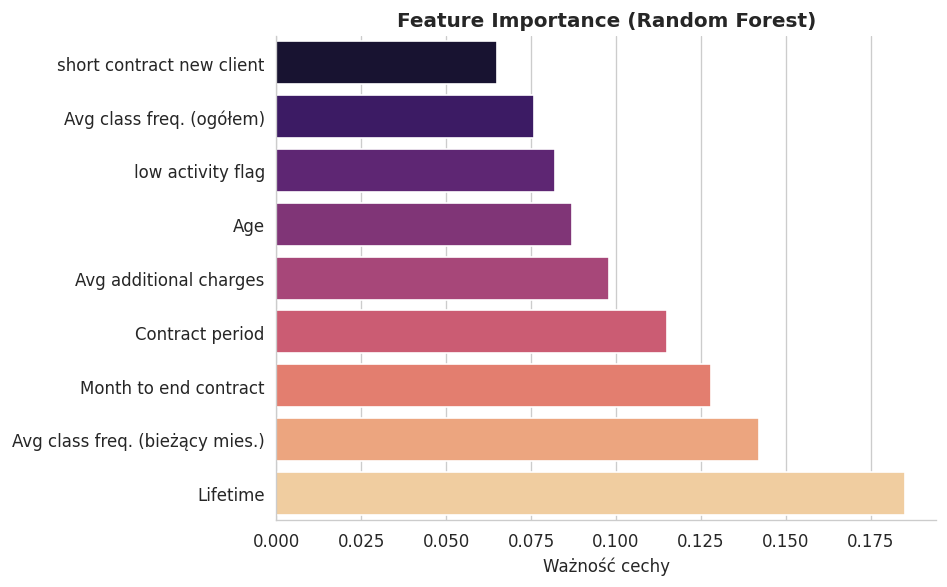

In [0]:
# ── WYKRES 4: Feature Importance (Random Forest) ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x="importance", y="feature",
    data=fi_data,
    hue="feature",
    palette="magma",
    legend=False,
    ax=ax,
)
ax.set_title("Feature Importance (Random Forest)", fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("Ważność cechy")

plt.tight_layout()
display(fig)
plt.close(fig)

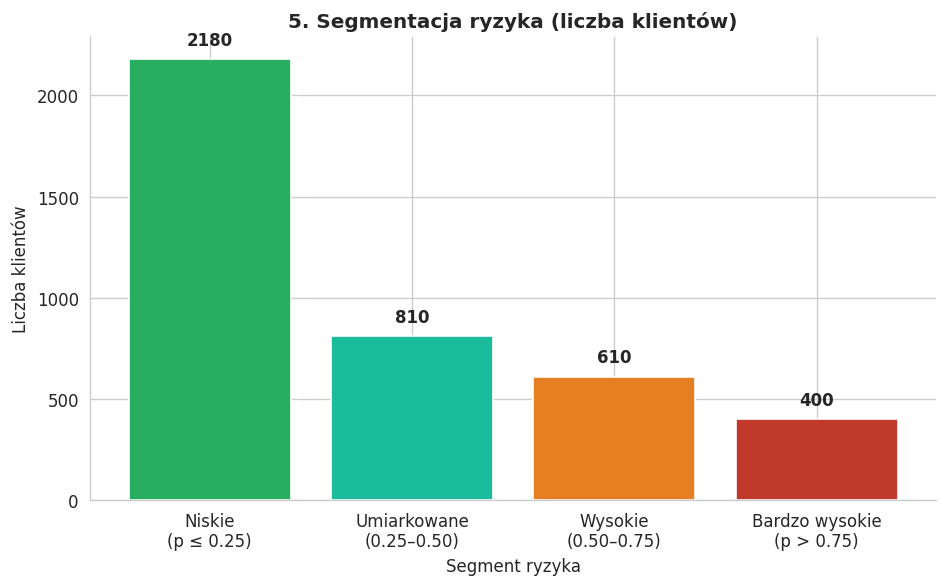

In [0]:
# ── WYKRES 5: Segmentacja ryzyka ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(x=seg_labels, height=seg_counts, color=seg_colors)
ax.set_title("5. Segmentacja ryzyka (liczba klientów)", fontweight="bold")
ax.set_ylabel("Liczba klientów")
ax.set_xlabel("Segment ryzyka")

for i, count in enumerate(seg_counts):
    ax.text(i, count + 50, str(count), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
display(fig)
plt.close(fig)

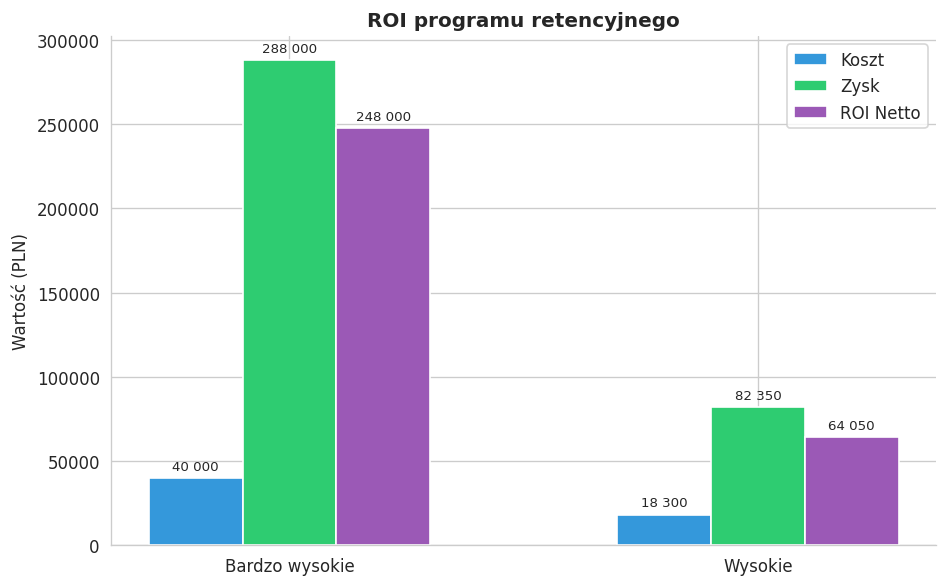

In [0]:
# ── WYKRES 6: ROI programu retencyjnego ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

width = 0.2
r = np.arange(len(roi_segs))

ax.bar(r - width, koszt,     width=width, label="Koszt",    color="#3498db")
ax.bar(r,         zysk,      width=width, label="Zysk",     color="#2ecc71")
ax.bar(r + width, roi_netto, width=width, label="ROI Netto",color="#9b59b6")

ax.set_title("ROI programu retencyjnego", fontweight="bold")
ax.set_xticks(r)
ax.set_xticklabels(roi_segs)
ax.set_ylabel("Wartość (PLN)")
ax.legend()

# etykiety wartości nad słupkami
for rect in ax.patches:
    h = rect.get_height()
    ax.text(
        rect.get_x() + rect.get_width() / 2,
        h + 3_000,
        f"{int(h):,}".replace(",", " "),
        ha="center", va="bottom", fontsize=8
    )

plt.tight_layout()
display(fig)
plt.close(fig)